# Por qué el Transformer no se adopta ahora — con evidencia, no con intuición

Este notebook reúne, en un solo sitio y con datos reales (no ilustrativos), toda la evidencia
acumulada en el proyecto para justificar una decisión concreta: **no seguir invirtiendo tiempo en
el Transformer (F13) de aquí al cierre del 9 de septiembre.**

No es una decisión estética ni una intuición — son cinco líneas de evidencia independientes,
algunas nuestras y algunas del resto del equipo, que apuntan todas en la misma dirección.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# --- Datos del equipo: 7 familias x 3 semillas sobre la matriz nucleo (production/models/por_semilla.csv) ---
semillas = pd.read_csv("../production/models/por_semilla.csv")

# --- Nuestros propios resultados sobre la misma matriz nucleo ---
lightgbm_nucleo = {"modelo": "LightGBM (nosotros)", "MAE_test": 12.92, "captura_test_%": 91.0, "pico_1h_test_%": 79.4}
transformer_min = pd.read_csv("../data_temp/transformer_minimo_resumen.csv").iloc[0]
transformer_row = {"modelo": "Transformer mínimo (nosotros)", "MAE_test": transformer_min["MAE"],
                    "captura_test_%": transformer_min["captura_arbitraje_%"], "pico_1h_test_%": transformer_min["pico_1h_%"]}

# --- Referencia: ensemble y naive del informe del equipo (29-ago noche) ---
ensemble_naive = pd.DataFrame([
    {"modelo": "Ensemble (7 familias, equipo)", "MAE_test": 11.95, "captura_test_%": 91.56, "pico_1h_test_%": 78.20},
    {"modelo": "naive D (referencia)", "MAE_test": 16.70, "captura_test_%": 86.58, "pico_1h_test_%": 68.25},
])

print(f"{len(semillas)} corridas (7 familias x 3 semillas) + nuestros 2 resultados propios")
semillas.head()

24 corridas (7 familias x 3 semillas) + nuestros 2 resultados propios


,familia,semilla,parametros,MAE_val,MAE_test,captura_val_%,captura_test_%,pico_1h_test_%,vs_naive_val_%
0,gru,42,196129,13.751,12.765,88.59,88.86,77.73,-31.1
1,gru,43,196129,13.626,12.926,88.01,88.46,77.73,-31.7
2,gru,44,196129,13.379,12.879,88.82,90.29,75.83,-32.9
3,conv1d_lstm,42,286305,14.528,13.677,87.71,89.90,77.25,-27.2
4,conv1d_lstm,43,286305,14.332,13.363,87.90,89.17,75.36,-28.1


## 1. Dónde se ubica el Transformer entre TODO lo que ya se probó

No es el único intento de "ir más allá de LightGBM" — el equipo ya comparó 5 arquitecturas de
deep learning (GRU, LSTM, Conv1D+LSTM, dos variantes de Seq2Seq) con 3 semillas cada una, más
nuestro LightGBM y nuestro Transformer, todos sobre la misma matriz (`nucleo`).

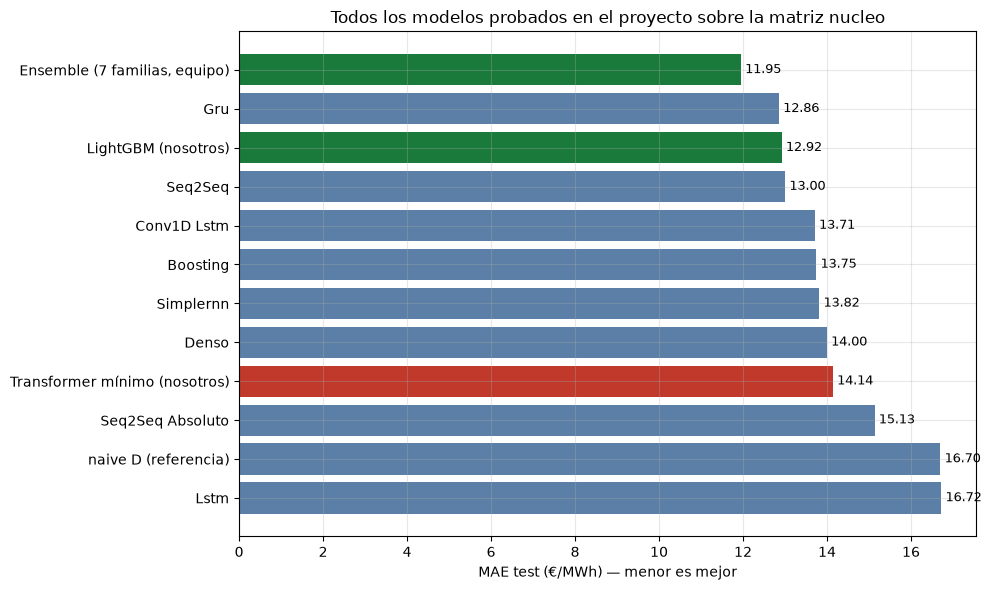


El Transformer mínimo queda en el puesto 9 de 12 — no explora territorio nuevo, siete arquitecturas ya cubrieron ese espacio.


In [2]:
resumen_familia = (semillas.groupby("familia")["MAE_test"].mean()
                    .reset_index().rename(columns={"familia": "modelo"}))
resumen_familia["modelo"] = resumen_familia["modelo"].str.replace("_", " ").str.title()

todos = pd.concat([resumen_familia, pd.DataFrame([lightgbm_nucleo, transformer_row]), ensemble_naive],
                   ignore_index=True).sort_values("MAE_test")

fig, ax = plt.subplots(figsize=(10, 6))
colores = ["#c0392b" if "Transformer" in m else ("#1a7a3c" if "nosotros" in m or "Ensemble" in m else "#5b7fa6")
           for m in todos["modelo"]]
ax.barh(todos["modelo"], todos["MAE_test"], color=colores)
ax.set_xlabel("MAE test (€/MWh) — menor es mejor")
ax.set_title("Todos los modelos probados en el proyecto sobre la matriz nucleo")
ax.invert_yaxis()
for i, v in enumerate(todos["MAE_test"]):
    ax.text(v + 0.1, i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

print("\nEl Transformer mínimo queda en el puesto",
      int(todos.reset_index(drop=True).query('modelo.str.contains("Transformer")', engine="python").index[0]) + 1,
      f"de {len(todos)} — no explora territorio nuevo, siete arquitecturas ya cubrieron ese espacio.")

## 2. El ruido de inicialización es más grande que lo que hay que ganar

Un hallazgo del propio equipo (mismo modelo, mismo código, mismos datos, solo cambia la semilla):
el MAE de test puede moverse más de 1 €/MWh sin que nada real haya cambiado. Antes de intentar
"mejorar" con una arquitectura nueva, hay que saber cuánto margen de mejora sería siquiera
detectable.

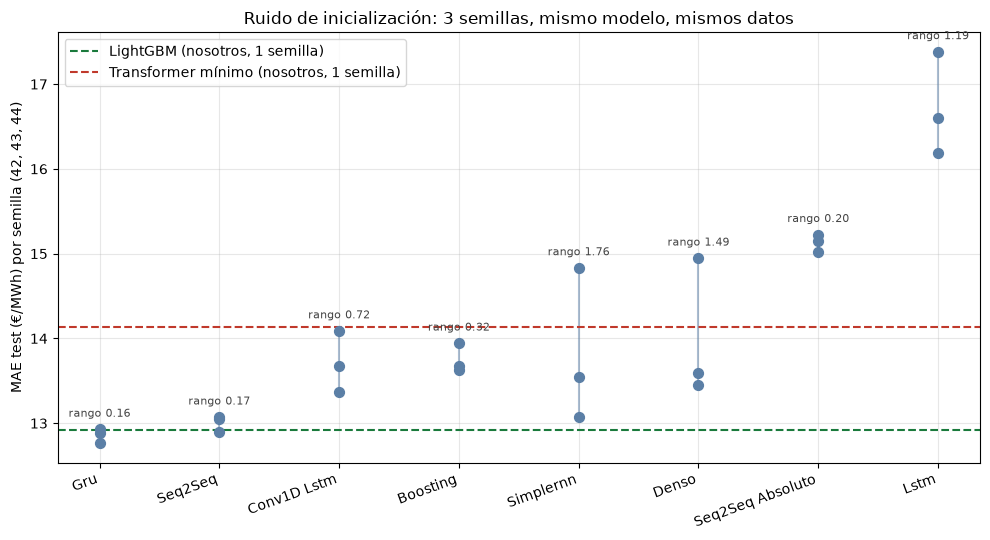


Rango medio entre semillas, por familia: 0.75 EUR/MWh
Diferencia LightGBM vs nuestro Transformer (una sola semilla cada uno): 1.22 EUR/MWh


In [3]:
fig, ax = plt.subplots(figsize=(10, 5.5))
familias_orden = semillas.groupby("familia")["MAE_test"].mean().sort_values().index
for i, fam in enumerate(familias_orden):
    vals = semillas.loc[semillas["familia"] == fam, "MAE_test"]
    ax.scatter([i] * len(vals), vals, color="#5b7fa6", zorder=3, s=50)
    ax.plot([i, i], [vals.min(), vals.max()], color="#5b7fa6", alpha=0.5, zorder=2)
    ax.annotate(f"rango {vals.max()-vals.min():.2f}", (i, vals.max() + 0.15), ha="center", fontsize=8, color="#444")

ax.axhline(lightgbm_nucleo["MAE_test"], color="#1a7a3c", linestyle="--", label="LightGBM (nosotros, 1 semilla)")
ax.axhline(transformer_row["MAE_test"], color="#c0392b", linestyle="--", label="Transformer mínimo (nosotros, 1 semilla)")
ax.set_xticks(range(len(familias_orden)))
ax.set_xticklabels([f.replace("_", " ").title() for f in familias_orden], rotation=20, ha="right")
ax.set_ylabel("MAE test (€/MWh) por semilla (42, 43, 44)")
ax.set_title("Ruido de inicialización: 3 semillas, mismo modelo, mismos datos")
ax.legend()
plt.tight_layout(); plt.show()

rango_medio = (semillas.groupby("familia")["MAE_test"].agg(lambda s: s.max() - s.min())).mean()
print(f"\nRango medio entre semillas, por familia: {rango_medio:.2f} EUR/MWh")
print(f"Diferencia LightGBM vs nuestro Transformer (una sola semilla cada uno): "
      f"{transformer_row['MAE_test'] - lightgbm_nucleo['MAE_test']:.2f} EUR/MWh")

**Lectura**: la diferencia entre nuestro Transformer y LightGBM (~1,2 €/MWh) es mayor que el
ruido típico entre semillas de una misma familia — así que probablemente es una diferencia real,
no ruido. Pero eso funciona en las dos direcciones: para saber si una *mejora* futura del
Transformer es real (no una semilla afortunada), haría falta repetirlo con varias semillas como
hizo el equipo — trabajo adicional real, no una tarde.

## 3. El objetivo del proyecto no es bajar el MAE — es capturar valor económico

Siete casos ya documentados por el equipo (más el nuestro, van ocho) donde bajar el MAE **cuesta**
captura de arbitraje. Si el objetivo real es la batería, perseguir un MAE más bajo con una
arquitectura más compleja puede ir en la dirección equivocada.

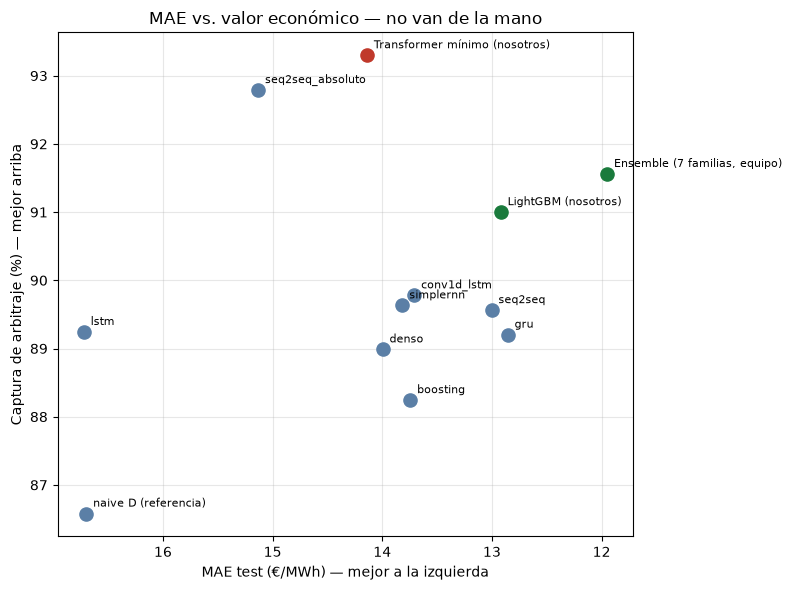

In [4]:
resumen_captura = (semillas.groupby("familia")[["MAE_test", "captura_test_%"]].mean()
                    .reset_index().rename(columns={"familia": "modelo"}))
todos_captura = pd.concat([resumen_captura, pd.DataFrame([lightgbm_nucleo, transformer_row]), ensemble_naive],
                           ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 6))
for _, r in todos_captura.iterrows():
    color = "#c0392b" if "Transformer" in r["modelo"] else ("#1a7a3c" if ("nosotros" in r["modelo"] or "Ensemble" in r["modelo"]) else "#5b7fa6")
    ax.scatter(r["MAE_test"], r["captura_test_%"], s=90, color=color, zorder=3)
    ax.annotate(r["modelo"], (r["MAE_test"], r["captura_test_%"]), fontsize=8,
                xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("MAE test (€/MWh) — mejor a la izquierda")
ax.set_ylabel("Captura de arbitraje (%) — mejor arriba")
ax.set_title("MAE vs. valor económico — no van de la mano")
ax.invert_xaxis()
plt.tight_layout(); plt.show()

**Lectura**: el Transformer, pese a tener el peor MAE del grupo, no tiene la peor captura — está
en línea con LightGBM y por encima de varios modelos con mejor MAE. Confirma, con una octava
observación, que MAE y captura son objetivos distintos — y que "mejorar con un Transformer" solo
tiene sentido si el objetivo es específicamente el valor económico, no el error puntual.

## 4. Nuestra propia corrida — dónde se estanca, no solo dónde termina

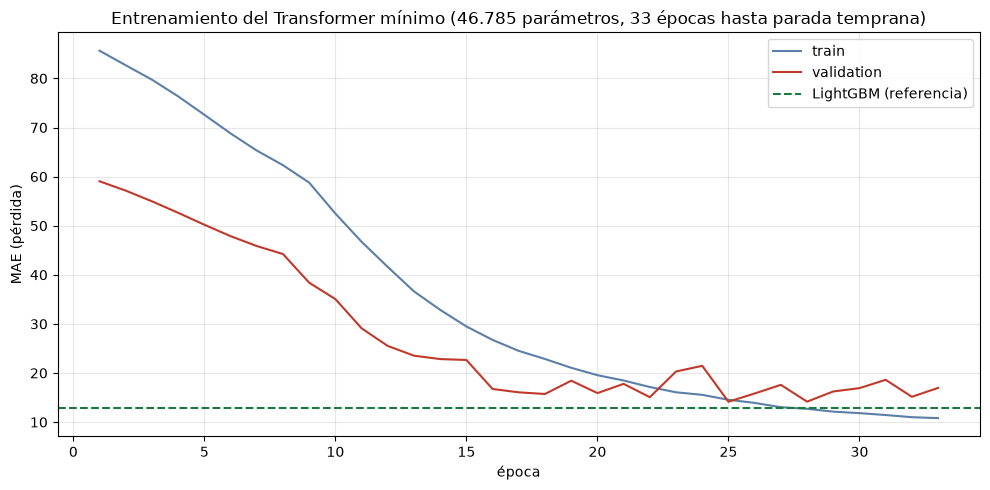

El train sigue bajando (sobreajuste incipiente) mientras el val se estanca alrededor de 14-16,
bastante por encima de la referencia de LightGBM -- no es un problema de 'darle mas tiempo',
es el techo de lo que este planteamiento consigue con los datos disponibles.


In [5]:
train_loss = [85.6429,82.6774,79.7418,76.3424,72.5940,68.7989,65.3079,62.3248,58.7765,52.4798,
              46.7281,41.5883,36.6203,32.8551,29.4746,26.7374,24.4964,22.8510,21.0579,19.5506,
              18.4674,17.1451,16.0682,15.5480,14.5427,13.9072,13.0320,12.6995,12.1288,11.8227,
              11.4375,10.9958,10.8058]
val_loss = [59.0465,57.1412,54.9678,52.6279,50.1966,47.8700,45.8560,44.2273,38.3941,35.0522,
            29.0991,25.5050,23.5243,22.8350,22.6479,16.7412,16.0562,15.7234,18.4283,15.9091,
            17.7838,15.0744,20.3037,21.4582,14.1425,15.8262,17.5845,14.1642,16.2355,16.9146,
            18.6118,15.1489,16.9559]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_loss)+1), train_loss, label="train", color="#5b7fa6")
ax.plot(range(1, len(val_loss)+1), val_loss, label="validation", color="#c0392b")
ax.axhline(lightgbm_nucleo["MAE_test"], color="#1a7a3c", linestyle="--", label="LightGBM (referencia)")
ax.set_xlabel("época"); ax.set_ylabel("MAE (pérdida)")
ax.set_title("Entrenamiento del Transformer mínimo (46.785 parámetros, 33 épocas hasta parada temprana)")
ax.legend()
plt.tight_layout(); plt.show()

print("El train sigue bajando (sobreajuste incipiente) mientras el val se estanca alrededor de 14-16,")
print("bastante por encima de la referencia de LightGBM -- no es un problema de 'darle mas tiempo',")
print("es el techo de lo que este planteamiento consigue con los datos disponibles.")

## 5. La literatura ya lo advertía, antes de correr un solo experimento

Zeng, Chen, Zhang y Xu, *"Are Transformers Effective for Time Series Forecasting?"*
(AAAI 2023, [arXiv:2205.13504](https://arxiv.org/abs/2205.13504)): modelos lineales de una sola
capa igualan o superan a varios Transformers de forecasting de largo plazo en benchmarks
establecidos. El argumento: la auto-atención es invariante al orden de la entrada, y por eso
pierde precisamente la información temporal que el problema necesita. Con ~1.800 días de
entrenamiento, este proyecto está lejos del régimen de datos donde un Transformer suele justificar
su complejidad frente a árboles de gradiente o incluso modelos lineales.

## Conclusión

Cinco líneas de evidencia independientes, no una sola:

1. **Territorio ya cubierto** — 7 arquitecturas de deep learning ya comparadas, con más rigor
   (3 semillas) del que un experimento nuevo aportaría de entrada.
2. **El ruido domina las diferencias pequeñas** — cualquier "mejora" del Transformer necesitaría
   varias semillas para poder confiar en ella, no es un experimento de una tarde.
3. **El objetivo no es MAE, es captura de arbitraje** — el Transformer no gana ahí tampoco de
   forma clara frente a lo que ya existe y está en producción.
4. **Nuestra propia corrida se estanca claramente por encima de LightGBM**, sin señales de que
   más tiempo de entrenamiento lo resuelva.
5. **La literatura académica ya anticipaba este resultado** antes de gastar un solo ciclo de GPU.

Y una razón más, de calendario: el equipo ya declaró F13 "prescindible" en tres informes de
estado sucesivos, con los modelos de producción ya entrenados, subidos y sirviendo en el VPS. El
9 de septiembre es el cierre total del proyecto. Cada hora en el Transformer es una hora que no
va a la memoria, que es el entregable evaluado.

**Esta decisión queda documentada aquí, con datos, para poder explicarla en la defensa si el
tribunal pregunta por qué no se usó — no como "no dio tiempo", sino como una decisión informada.**